# Intraday seasonality: volume U-shape, volatility smile, spread decay

Almost every execution and alpha model conditions on time of day. Volume
concentrates at the open and close, volatility peaks in the first hour,
spreads narrow through the morning.

Measuring these curves correctly is a timezone problem before it is a
statistics problem. "09:30 New York" drifts against UTC at every DST
transition, and a naive `EXTRACT(hour)` on UTC timestamps smears buckets by an
hour twice a year.

`time_bucket` takes an IANA timezone as its third argument, so buckets align
to *wall-clock* time in that zone, DST included.

We measure the curves twice: on synthetic tick data, where we know which
effects the generator does and does not contain, and on real SPY/QQQ hourly
bars.

## Terms used here

| term                 | meaning |
| -------------------- | --- |
| intraday seasonality | patterns that repeat by time of day rather than across dates |
| U-shape              | the volume curve: heavy at the open and close, thin in the middle of the day |
| volatility smile     | here the same U-shape in volatility, unrelated to the options smile |
| spread decay         | quoted spreads narrowing through the morning as uncertainty clears |
| session              | one trading day as the exchange defines it, e.g. 09:30-16:00 New York |
| DST                  | daylight saving time; sessions are fixed in local time, so their UTC offset shifts |
| IANA timezone        | a named zone such as `America/New_York`, which carries its own DST rules |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, count_star, sql_expr, time_bucket
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_seasonality"), create=True)

## 1. The data

Two feeds from `cu.make_trades_and_quotes`, five sessions, three symbols.
Trades are one row per print, quotes one row per change in the best bid or
offer.

| table | columns |
| --- | --- |
| `trades` | `ts`, `symbol`, `price`, `size`, `exchange`, `side` |
| `quotes` | `ts`, `symbol`, `bid`, `ask`, `bid_size`, `ask_size` |

`ts` is `timestamp[us, tz=UTC]` and ascending in both.

In [2]:
trades, quotes = cu.make_trades_and_quotes(days=5)
print(f"trades: {trades.num_rows:,} rows   quotes: {quotes.num_rows:,} rows")
trades.to_pandas().head()

trades: 304,136 rows   quotes: 909,937 rows


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.208519+00:00,AAPL,265.01,400,IEX,S
1,2026-06-01 13:30:00.480445+00:00,AAPL,265.01,1,ARCA,S
2,2026-06-01 13:30:00.505343+00:00,AAPL,265.01,100,IEX,S
3,2026-06-01 13:30:00.756358+00:00,MSFT,363.02,1,NYSE,B
4,2026-06-01 13:30:00.760070+00:00,AAPL,265.07,1,NASDAQ,B


In [3]:
quotes.to_pandas().head()

,ts,symbol,bid,ask,bid_size,ask_size
0,2026-06-01 13:30:00.005202+00:00,NVDA,319.24,319.26,800,1200
1,2026-06-01 13:30:00.029856+00:00,AAPL,265.02,265.05,1200,300
2,2026-06-01 13:30:00.074727+00:00,MSFT,362.97,363.03,100,400
3,2026-06-01 13:30:00.158142+00:00,NVDA,319.22,319.29,700,200
4,2026-06-01 13:30:00.196878+00:00,AAPL,265.00,265.07,900,600


The real side is 60 days of hourly SPY and QQQ bars from `cu.fetch_intraday`:
`ts`, `symbol`, `open`, `high`, `low`, `close`, `volume`, one row per symbol
per hour.

In [4]:
bars = cu.fetch_intraday(["SPY", "QQQ"], period="60d", interval="1h").sort_by(
    [("ts", "ascending"), ("symbol", "ascending")]
)
print(f"bars_1h: {bars.num_rows:,} rows x {bars.num_columns} columns")
bars.to_pandas().head()

bars_1h: 840 rows x 7 columns


,ts,symbol,open,high,low,close,volume
0,2026-04-27 13:30:00+00:00,QQQ,663.385010,663.849976,660.690002,662.169983,9878956
1,2026-04-27 13:30:00+00:00,SPY,713.169983,714.409302,712.599976,713.445007,7962185
2,2026-04-27 14:30:00+00:00,QQQ,662.185974,663.280029,660.950012,661.820007,4578008
3,2026-04-27 14:30:00+00:00,SPY,713.459229,714.450012,712.294983,713.000000,3815390
4,2026-04-27 15:30:00+00:00,QQQ,661.830017,662.909973,661.609985,662.580017,2850422


In [5]:
for name, tbl in (("trades", trades), ("quotes", quotes)):
    db.create_table(name, tbl.schema, time_column="ts", sort_key=["ts", "symbol"])
    db.append(name, tbl, note="5-day synthetic feed")

# append enforces the declared sort key, so order by (ts, symbol) explicitly
db.create_table("bars_1h", bars.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("bars_1h", bars, note="real SPY/QQQ hourly bars")
{t: len(db.read(t)) for t in db.tables()}

{'bars_1h': 840, 'quotes': 909937, 'trades': 304136}

## 2. Volume by 30 minutes of the New York day

`time_bucket('30m', ts, 'America/New_York')` anchors bucket boundaries to NY
wall-clock time.

Within one June week that is indistinguishable from UTC bucketing. Across the
March and November DST transitions, the NY buckets stay pinned to 09:30,
10:00 and so on, while UTC buckets would shift by an hour mid-sample and split
every time-of-day average into two blurred populations. Same query, correct
all year.

The wall-clock label comes from converting the bucket start to NY time in
pandas.

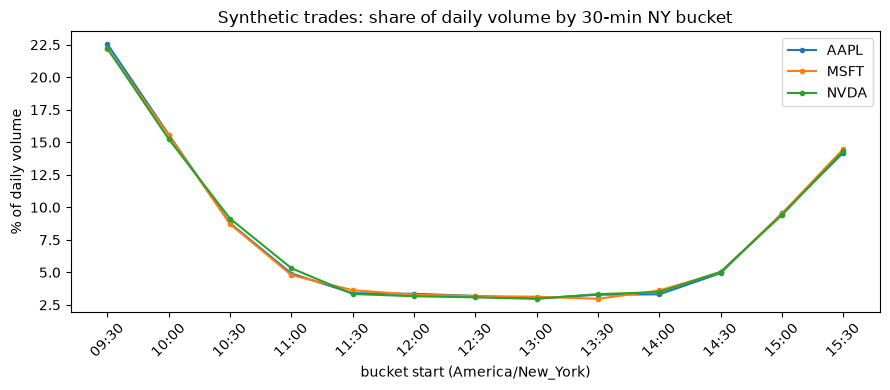

In [6]:
NY30 = time_bucket("30m", col("ts"), timezone="America/New_York")

vol30 = (
    db.table("trades")
    .group_by(NY30.alias("bucket"), "symbol")
    .agg(volume=col("size").sum(), n_trades=count_star())
    .sort(["bucket", "symbol"])
    .to_pandas()
)
vol30["tod"] = vol30["bucket"].dt.tz_convert("America/New_York").dt.strftime("%H:%M")

profile = (
    vol30.groupby(["tod", "symbol"])["volume"].mean().unstack()  # avg across the 5 days
)
profile_share = profile / profile.sum()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for sym in profile_share.columns:
    ax.plot(profile_share.index, profile_share[sym] * 100, marker="o", ms=3, label=sym)
ax.set_title("Synthetic trades: share of daily volume by 30-min NY bucket")
ax.set_xlabel("bucket start (America/New_York)")
ax.set_ylabel("% of daily volume")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()

The U-shape is pronounced, and by construction. The generator concentrates 40%
of arrivals near the open and 20% near the close, mimicking the real pattern.

Here are the summary numbers an execution scheduler would want:

In [7]:
first_last = pd.DataFrame(
    {
        "first 30m share": profile_share.loc["09:30"],
        "last 30m share": profile_share.loc["15:30"],
        "midday hour share": profile_share.loc["12:00"] + profile_share.loc["12:30"],
    }
).T
(first_last * 100).round(1)

symbol,AAPL,MSFT,NVDA
first 30m share,22.5,22.2,22.2
last 30m share,14.2,14.5,14.3
midday hour share,6.5,6.5,6.2


## 3. Volatility and spreads by time of day: an honest null

The same bucketing applied to 30-minute bar returns gives the volatility
smile, and applied to quotes gives spread decay.

Here the synthetic data *cannot* show the real-world effect, and it is worth
being precise about why. The generator's price is a homogeneous diffusion in
calendar time, so variance is proportional to elapsed time regardless of trade
intensity, and its spread is drawn once per symbol-day.

So the honest expectation is a *flat* volatility curve and a *flat* spread
curve. That is what we get, and it makes a useful placebo: any curvature the
pipeline showed here would be a bug in the pipeline.

In [8]:
smile = (
    db.table("trades")
    .group_by(NY30.alias("bucket"), "symbol")
    .agg(open=col("price").first("ts"), close=col("price").last("ts"))
    .select("bucket", "symbol", bar_ret=col("close") / col("open") - 1)
    .sort("bucket")
    .to_pandas()
)
smile["tod"] = smile["bucket"].dt.tz_convert("America/New_York").dt.strftime("%H:%M")
vol_by_tod = smile.groupby("tod")["bar_ret"].std() * 1e4

# each bucket std rests on only 15 bar returns (5 days x 3 symbols), so test
# flatness properly: standardize per symbol, then Levene's test across buckets
from scipy import stats

smile["z"] = smile.groupby("symbol")["bar_ret"].transform(lambda s: s / s.std())
levene = stats.levene(*[g["z"].values for _, g in smile.groupby("tod")])
print(f"Levene test for equal variance across buckets: p = {levene.pvalue:.2f}")

spread = (
    db.table("quotes")
    .group_by(NY30.alias("bucket"), "symbol")
    .agg(spread_bps=((col("ask") - col("bid")) / ((col("ask") + col("bid")) / 2)).mean() * 10000)
    .sort("bucket")
    .to_pandas()
)
spread["tod"] = spread["bucket"].dt.tz_convert("America/New_York").dt.strftime("%H:%M")
spread_by_tod = spread.groupby("tod")["spread_bps"].mean()

pd.DataFrame(
    {
        "bar-return std (bps)": vol_by_tod,
        "quoted spread (bps)": spread_by_tod,
    }
).loc[["09:30", "10:30", "12:30", "14:30", "15:30"]].round(2)

Levene test for equal variance across buckets: p = 0.42


,bar-return std (bps),quoted spread (bps)
tod,,
09:30,54.10,1.75
10:30,39.25,1.75
12:30,41.54,1.75
14:30,49.30,1.75
15:30,29.50,1.75


Flat, as predicted. The raw bucket stds wiggle, since each rests on 15 bar
returns, but Levene's test finds no evidence of unequal variance across
buckets, and the spread column is constant to the basis point.

The method is validated and the effect is absent from this generator. Real
markets show roughly 2 to 3x first-hour volatility, and spreads that start
wide and tighten within minutes. The volatility half of that comes next, from
real data.

One more timezone note while we are here. With `'1d'` widths the timezone
argument controls where the *day* boundary falls, which for a 24h asset class
decides which trades belong to "Monday".

In [9]:
(
    db.table("trades")
    .group_by(
        time_bucket("1d", col("ts")).alias("day_utc"),
        time_bucket("1d", col("ts"), timezone="America/New_York").alias("day_ny"),
    )
    .agg(volume=col("size").sum())
    .sort("day_utc")
    .limit(3)
    .to_pandas()
)

,day_utc,day_ny,volume
0,2026-06-01 00:00:00+00:00,2026-06-01 04:00:00+00:00,4664004
1,2026-06-02 00:00:00+00:00,2026-06-02 04:00:00+00:00,4313257
2,2026-06-03 00:00:00+00:00,2026-06-03 04:00:00+00:00,3602684


For US equities the session sits inside one UTC day, so both groupings agree
and only the labels differ, with NY midnight at 04:00 UTC. For FX or crypto
flowing through 00:00 UTC, the choice changes every daily number. The 24/7
markets recipe covers that case.

## 4. The real thing: SPY and QQQ, 60 days of hourly bars

Returns per bar come from `lag()` in SQL, then the same wall-clock grouping.

One caveat kept honest: this cached sample, late April to July, does not
straddle a DST transition, so UTC bucketing would happen to work here too. The
NY-anchored version is the one that keeps working in March.

SPY first-hour volume share: 21.8%   last-hour: 20.8%

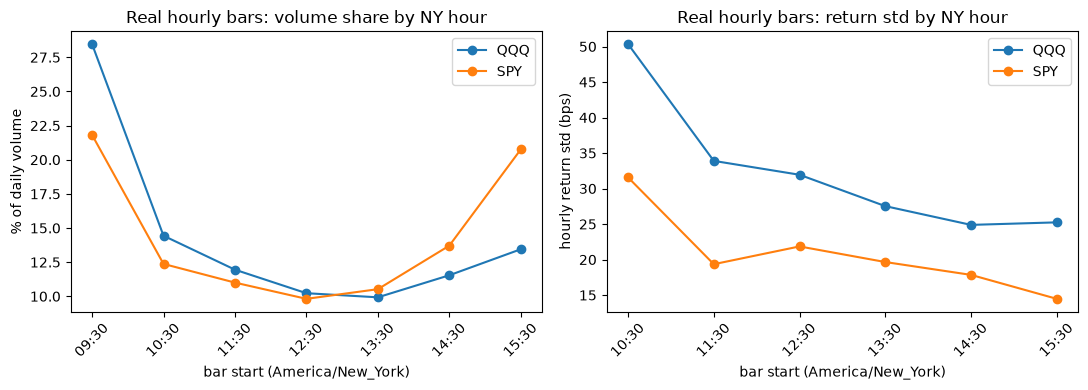

In [10]:
real = (
    db.table("bars_1h")
    .select(
        "ts", "symbol", "volume",
        ret=col("close") / sql_expr("lag(close)").over(partition_by="symbol", order_by="ts") - 1,
    )
    .sort("ts")
    .to_pandas()
)
real["tod"] = real["ts"].dt.tz_convert("America/New_York").dt.strftime("%H:%M")
# first bar of each day carries an overnight return -> exclude from the smile
real.loc[real["tod"] == "09:30", "ret"] = np.nan

by_tod = real.groupby(["tod", "symbol"]).agg(
    avg_volume=("volume", "mean"), ret_std=("ret", "std")
)
share = by_tod["avg_volume"].unstack()
share = share / share.sum()
vol_curve = by_tod["ret_std"].unstack() * 1e4

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for sym in share.columns:
    axes[0].plot(share.index, share[sym] * 100, marker="o", label=sym)
    axes[1].plot(vol_curve.index, vol_curve[sym], marker="o", label=sym)
axes[0].set_title("Real hourly bars: volume share by NY hour")
axes[0].set_ylabel("% of daily volume")
axes[1].set_title("Real hourly bars: return std by NY hour")
axes[1].set_ylabel("hourly return std (bps)")
for ax in axes:
    ax.set_xlabel("bar start (America/New_York)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
fig.tight_layout()

print("SPY first-hour volume share: {:.1%}   last-hour: {:.1%}".format(
    share["SPY"].iloc[0], share["SPY"].iloc[-1]))

The real curves deliver what the synthetic ticks could not: the U-shaped
volume profile *and* an elevated post-open volatility that decays into midday.

The 09:30 bar is excluded from the smile, because its `lag()` return spans the
overnight gap. That is a classic subtlety worth encoding in the pipeline
rather than in a footnote.

## Takeaways

- `time_bucket(width, ts, 'America/New_York')` is the DST-safe way to build
  time-of-day statistics. Buckets pin to wall-clock sessions, so March and
  November do not smear your seasonal curves. With `'1d'` widths the same
  argument decides where the trading day starts.
- The whole pipeline is two GROUP BY queries per curve. Volume, bar returns
  and spreads each collapse from hundreds of thousands of ticks to a few dozen
  buckets inside the database.
- Synthetic data is a placebo, not a substitute. It reproduced the volume
  U-shape, which is built into the generator, and correctly showed *flat*
  volatility and spread curves, which are absent from it. The real SPY/QQQ
  bars supplied the volatility smile.
- Excluding the overnight return from the 09:30 bucket is the kind of one-line
  correctness detail that separates a usable seasonality curve from a subtly
  wrong one.

In [11]:
db.close()